In [41]:
import csv
import os

DIRECTORY = "C:/Users/emaom/OneDrive/Desktop/Seminarska naloga/SUROVI_PODATKI"
CSV_FILENAME = "nepremicnine_ljubljana.csv"
path = os.path.join(DIRECTORY, CSV_FILENAME)

In [42]:

cene = []
velikosti = []
leta = []

with open(path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        c_zapis = row["cena_€"]
        v_zapis = row["velikost_m2"]
        l_zapis = row["leto_izgradnje"]
        
        c_ocisceno = c_zapis.replace("€", "").replace(".", "").replace(",", ".").strip()
        v_ocisceno = v_zapis.replace(",", ".").strip()
        l_ocisceno = l_zapis.strip()
        
        try:
            cena = float(c_ocisceno)
            velikost = float(v_ocisceno)
            leto = int(l_ocisceno)
            
            cene.append(cena)
            velikosti.append(velikost)
            leta.append(leto)
        except ValueError:
            continue

In [55]:
skupaj_oglasov = len(cene)

if skupaj_oglasov > 0:
    povprecna_cena = sum(cene) / skupaj_oglasov
    povprecna_velikost = sum(velikosti) / skupaj_oglasov

    skupna_cena = sum(cene)
    skupna_povrsina = sum(velikosti)
    povprecna_cena_na_m2 = skupna_cena / skupna_povrsina if skupna_povrsina > 0 else 0

    print("ANALIZA NEPREMIČNIN V LJUBLJANI:")
    print(f"Število uspešno obdelanih oglasov: {skupaj_oglasov}")
    print(f"Povprečna cena nepremičnine: {povprecna_cena:,.2f} €")
    print(f"Povprečna velikost nepremičnine: {povprecna_velikost:.2f} m2")
    print(f"Povprečna cena na m2: {povprecna_cena_na_m2:,.2f} €/m2")
    print(f"Najdražja nepremičnina: {max(cene):,.2f} €")
    print(f"Najcenejša nepremičnina: {min(cene):,.2f} €")
else:
    print("V datoteki ni bilo ustreznih podatkov za izračun.")

ANALIZA NEPREMIČNIN V LJUBLJANI:
Število uspešno obdelanih oglasov: 671
Povprečna cena nepremičnine: 575,268.75 €
Povprečna velikost nepremičnine: 106.61 m2
Povprečna cena na m2: 5,396.11 €/m2
Najdražja nepremičnina: 3,200,000.00 €
Najcenejša nepremičnina: 9,500.00 €


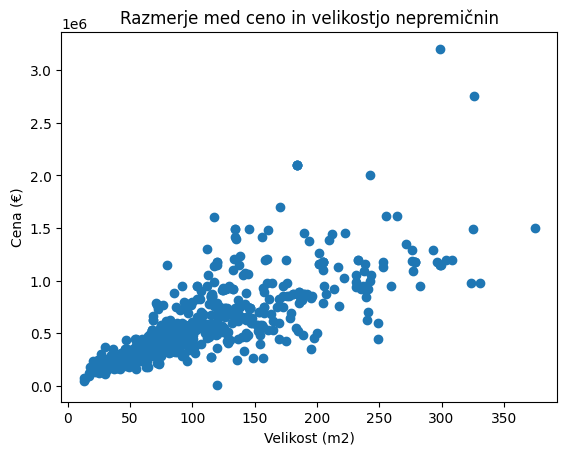

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(velikosti, cene)
plt.title("Razmerje med ceno in velikostjo nepremičnin")
plt.xlabel("Velikost (m2)")
plt.ylabel("Cena (€)")
plt.show()

In [58]:
cene_na_m2 = []
for c, v in zip(cene, velikosti):
    if v > 0:
        cene_na_m2.append(c / v)

if cene_na_m2:
    povprecna_m2 = sum(cene_na_m2) / len(cene_na_m2)
    print(f"Povprečna cena na m2: {povprecna_m2:,.2f} €/m2")
    print(f"Najvišja cena na m2: {max(cene_na_m2):,.2f} €/m2")
    print(f"Najnižja cena na m2: {min(cene_na_m2):,.2f} €/m2")

Povprečna cena na m2: 5,662.69 €/m2
Najvišja cena na m2: 14,357.05 €/m2
Najnižja cena na m2: 79.17 €/m2


Mediana cene nepremičnin: 461,900.00 €


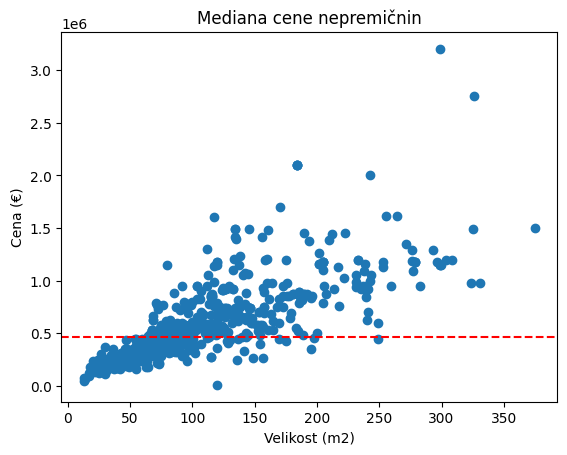

In [57]:
cene_urejene = sorted(cene)
n = len(cene_urejene)

if n % 2 == 1:
    mediana_cene = cene_urejene[n // 2]
else:
    mediana_cene = (cene_urejene[n // 2 - 1] + cene_urejene[n // 2]) / 2

print(f"Mediana cene nepremičnin: {mediana_cene:,.2f} €")

plt.scatter(velikosti, cene)
plt.title("Mediana cene nepremičnin")
plt.axhline(y=mediana_cene, color='red', linestyle='--')
plt.xlabel("Velikost (m2)")
plt.ylabel("Cena (€)")
plt.show()

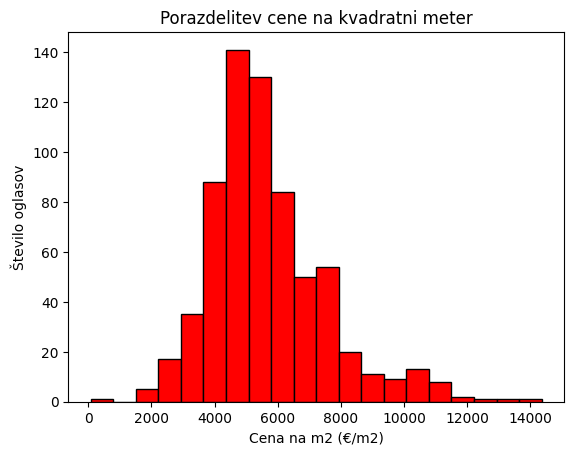

In [59]:
import matplotlib.pyplot as plt

cene_na_m2 = []
for c, v in zip(cene, velikosti):
    if v > 0:
        cene_na_m2.append(c / v)


plt.hist(cene_na_m2, bins=20, color='red', edgecolor='black')
plt.xlabel("Cena na m2 (€/m2)")
plt.ylabel("Število oglasov")
plt.title("Porazdelitev cene na kvadratni meter")
plt.show()

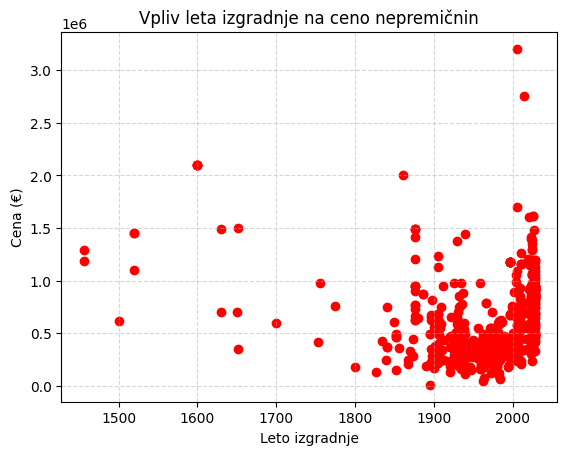

In [52]:
import matplotlib.pyplot as plt

plt.title("Vpliv leta izgradnje na ceno nepremičnin")
plt.scatter(leta, cene, color= 'red')
plt.xlabel("Leto izgradnje")
plt.ylabel("Cena (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [64]:
skupina_stara = []
skupina_nova = []

for c, v, l in zip(cene, velikosti, leta):
    if v > 0:
        cena_m2 = c / v
        if l < 2021:
            skupina_stara.append(cena_m2)
        else:
            skupina_nova.append(cena_m2)

if skupina_stara:
    print(f"Povprečna cena m2 (stara gradnja - pred 2021): {sum(skupina_stara) / len(skupina_stara):,.2f} €/m2")

if skupina_nova:
    print(f"Povprečna cena m2 (nova gradnja - 2021 in novejše): {sum(skupina_nova) / len(skupina_nova):,.2f} €/m2")

Povprečna cena m2 (stara gradnja - pred 2021): 5,518.92 €/m2
Povprečna cena m2 (nova gradnja - 2021 in novejše): 6,063.97 €/m2
